In [1]:
import torch
import torch.nn as nn

from data.transform import VideoTrainTransform,VideoValTransform
from data.video_dataset import create_datasets
from data.video_dataloader import load_dataloader

from models import get_model

from pathlib import Path

/home/lotson/projects/paper_warehouse_action_recognition/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
root=Path.cwd()
dataset_dir=root/"videos"/"mini_dataset"

In [3]:
model = get_model(model=4,
                  num_classes=5)

model.__class__.__name__

'SwinTransformer3d'

In [4]:
train_dataset,val_dataset=create_datasets(train_path=dataset_dir/"train",
                val_path=dataset_dir/"val",
                num_frames=16,
                strategy="uniform",
                train_transform=VideoTrainTransform(model=model),
                val_transform=VideoValTransform(model=model)
                )

In [5]:
train_dataloader=load_dataloader(train_dataset=train_dataset,
                val_dataset=val_dataset,
                batch_size=2,
                is_train_loader=True,
                num_workers=0,
                seed=42)

In [6]:
x,y=next(iter(train_dataloader))

In [7]:
x.shape

torch.Size([2, 16, 3, 64, 64])

In [20]:
from utils.helper_functions import plot_images

In [21]:
frames=x[0].squeeze(dim=0)
frames.shape

torch.Size([16, 3, 96, 96])

In [22]:
frames.permute(0,2,3,1).shape

torch.Size([16, 96, 96, 3])

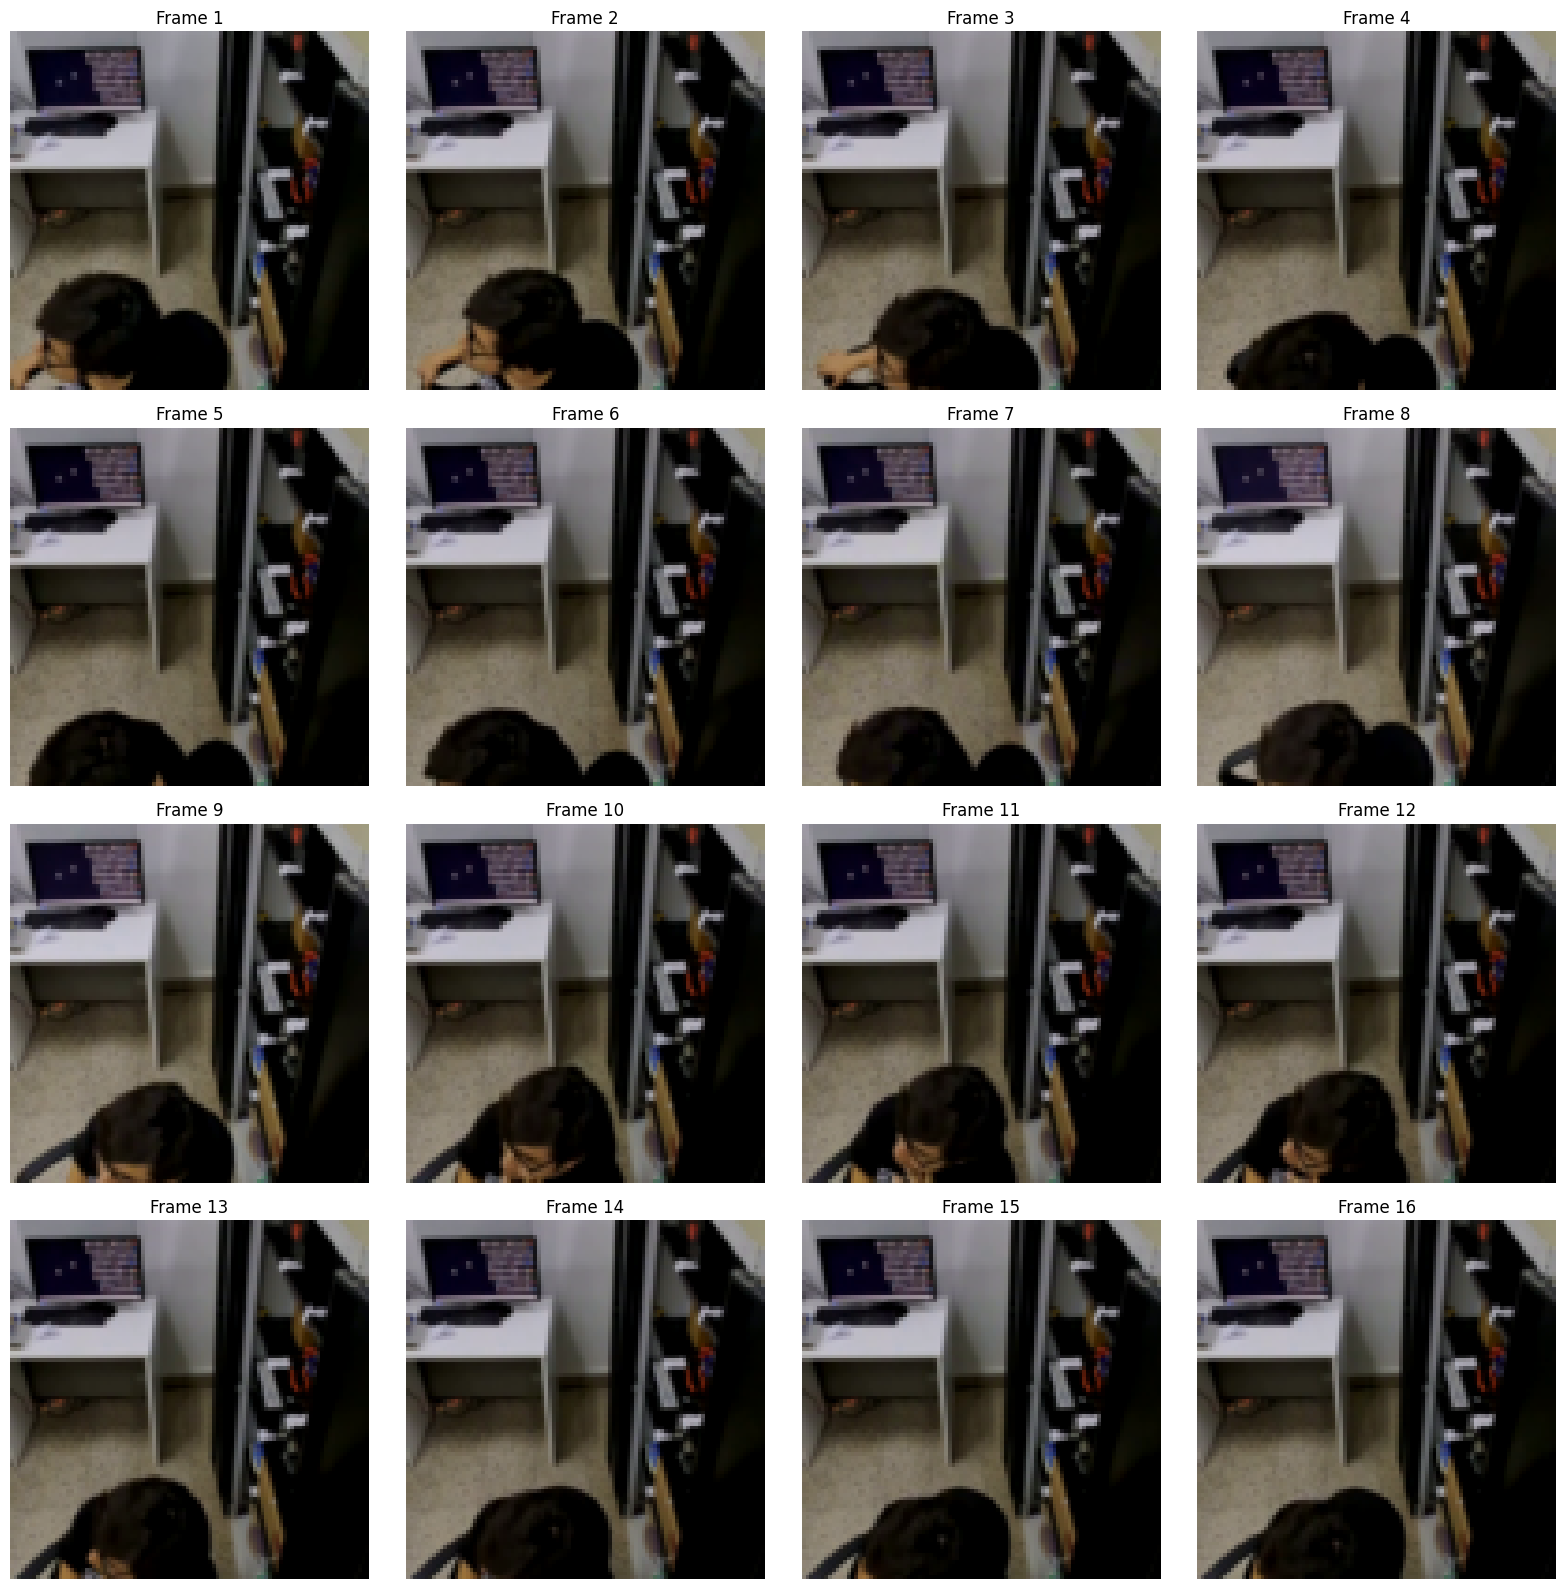

In [23]:
plot_images(frames.permute(0,2,3,1),4,4)

In [25]:
x.shape

torch.Size([2, 16, 3, 96, 96])

In [8]:
dummy_tensor=torch.randn((1,3,16,224,224))

dummy_tensor_2=torch.randn((1,3,16,112,112))

dummy_tensor_3=torch.randn((1,16,3,224,224))

In [9]:
model(dummy_tensor_3)

ImageClassifierOutput(loss=None, logits=tensor([[-0.6427, -0.4187,  0.1992,  0.8309,  0.0740]],
       grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)